# 🎓 Logistic Regression in University Life
## Student Academic Outcome Prediction — Pass or At-Risk?

---

**Domain:** Higher Education / Student Analytics  
**Algorithm:** Logistic Regression (Binary + Multiclass Classification)  
**Learning Objective:** Learn Logistic Regression on familiar, relatable data; critically examine its strengths, its blind spots, and the ethical issues that arise when applying ML to student outcomes.

---

### 🏫 Problem Statement

Universities want to identify students at risk of failing **before** exam season so that support services (tutoring, counselling, extra workshops) can be offered in time.

We have survey + administrative data for **500 students**. Our task:

| Label | Meaning |
|-------|----------|
| `0`   | **At Risk** — likely to fail or withdraw |
| `1`   | **Pass** — on track to pass all modules |

---

### 📋 Features

| Feature | Type | Description |
|---------|------|-------------|
| `attendance_pct` | float | % of lectures/labs attended |
| `assignment_avg` | float | Mean assignment score (0–100) |
| `study_hours_week` | float | Self-reported weekly study hours |
| `sleep_hours_night` | float | Average sleep per night |
| `part_time_work_hrs` | float | Weekly hours of paid work |
| `stress_score` | int | Self-reported stress (1–10) |
| `previous_gpa` | float | GPA from previous year (0–4) |
| `library_visits_month` | int | Library check-ins per month |
| `missed_deadlines` | int | Number of missed deadlines this semester |
| `first_gen_student` | binary | 1 if first in family to attend university |


## 0. Install Dependencies

In [1]:
# !pip install numpy pandas scikit-learn matplotlib seaborn

## 1. Generate Synthetic Student Dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)
N = 500

# ── Simulate correlated student features ──────────────────────────────────
# Passing students
n_pass = 320
pass_df = pd.DataFrame({
    'attendance_pct'       : np.clip(np.random.normal(78, 12, n_pass), 0, 100),
    'assignment_avg'       : np.clip(np.random.normal(65, 12, n_pass), 0, 100),
    'study_hours_week'     : np.clip(np.random.normal(18, 5,  n_pass), 0, 40),
    'sleep_hours_night'    : np.clip(np.random.normal(7.0, 0.8, n_pass), 4, 10),
    'part_time_work_hrs'   : np.clip(np.random.normal(8, 5,  n_pass), 0, 30),
    'stress_score'         : np.clip(np.random.normal(5, 2,  n_pass), 1, 10).astype(int),
    'previous_gpa'         : np.clip(np.random.normal(3.0, 0.5, n_pass), 0, 4),
    'library_visits_month' : np.clip(np.random.poisson(6, n_pass), 0, 20).astype(int),
    'missed_deadlines'     : np.clip(np.random.poisson(1, n_pass), 0, 10).astype(int),
    'first_gen_student'    : np.random.binomial(1, 0.3, n_pass),
    'outcome'              : 1
})

# At-risk students
n_risk = 180
risk_df = pd.DataFrame({
    'attendance_pct'       : np.clip(np.random.normal(52, 15, n_risk), 0, 100),
    'assignment_avg'       : np.clip(np.random.normal(45, 15, n_risk), 0, 100),
    'study_hours_week'     : np.clip(np.random.normal(8, 5,  n_risk), 0, 40),
    'sleep_hours_night'    : np.clip(np.random.normal(5.8, 1.2, n_risk), 3, 10),
    'part_time_work_hrs'   : np.clip(np.random.normal(18, 6,  n_risk), 0, 40),
    'stress_score'         : np.clip(np.random.normal(7.5, 1.5, n_risk), 1, 10).astype(int),
    'previous_gpa'         : np.clip(np.random.normal(2.0, 0.6, n_risk), 0, 4),
    'library_visits_month' : np.clip(np.random.poisson(2, n_risk), 0, 10).astype(int),
    'missed_deadlines'     : np.clip(np.random.poisson(4, n_risk), 0, 15).astype(int),
    'first_gen_student'    : np.random.binomial(1, 0.5, n_risk),
    'outcome'              : 0
})

df = pd.concat([pass_df, risk_df], ignore_index=True)
df = df.sample(frac=1, random_state=0).reset_index(drop=True)

print(f"Dataset shape  : {df.shape}")
print(f"Outcome counts : {df['outcome'].value_counts().to_dict()}  (0=At-Risk, 1=Pass)")
df.head()

Dataset shape  : (500, 11)
Outcome counts : {1: 320, 0: 180}  (0=At-Risk, 1=Pass)


,attendance_pct,assignment_avg,study_hours_week,sleep_hours_night,part_time_work_hrs,stress_score,previous_gpa,library_visits_month,missed_deadlines,first_gen_student,outcome
0,73.161877,47.641584,15.473208,6.424048,11.854185,1,3.185586,7,3,0,1
1,86.298465,72.078558,10.890401,6.636736,6.589021,5,3.404870,11,0,1,1
2,96.436525,67.857238,19.026663,7.254308,12.983798,8,2.936466,6,3,0,1
3,42.801943,25.646123,4.338676,7.131470,18.234423,8,2.314693,2,2,0,0
4,52.695421,60.214037,11.156219,6.548021,14.421510,7,3.695462,2,3,1,0


## 2. Exploratory Data Analysis

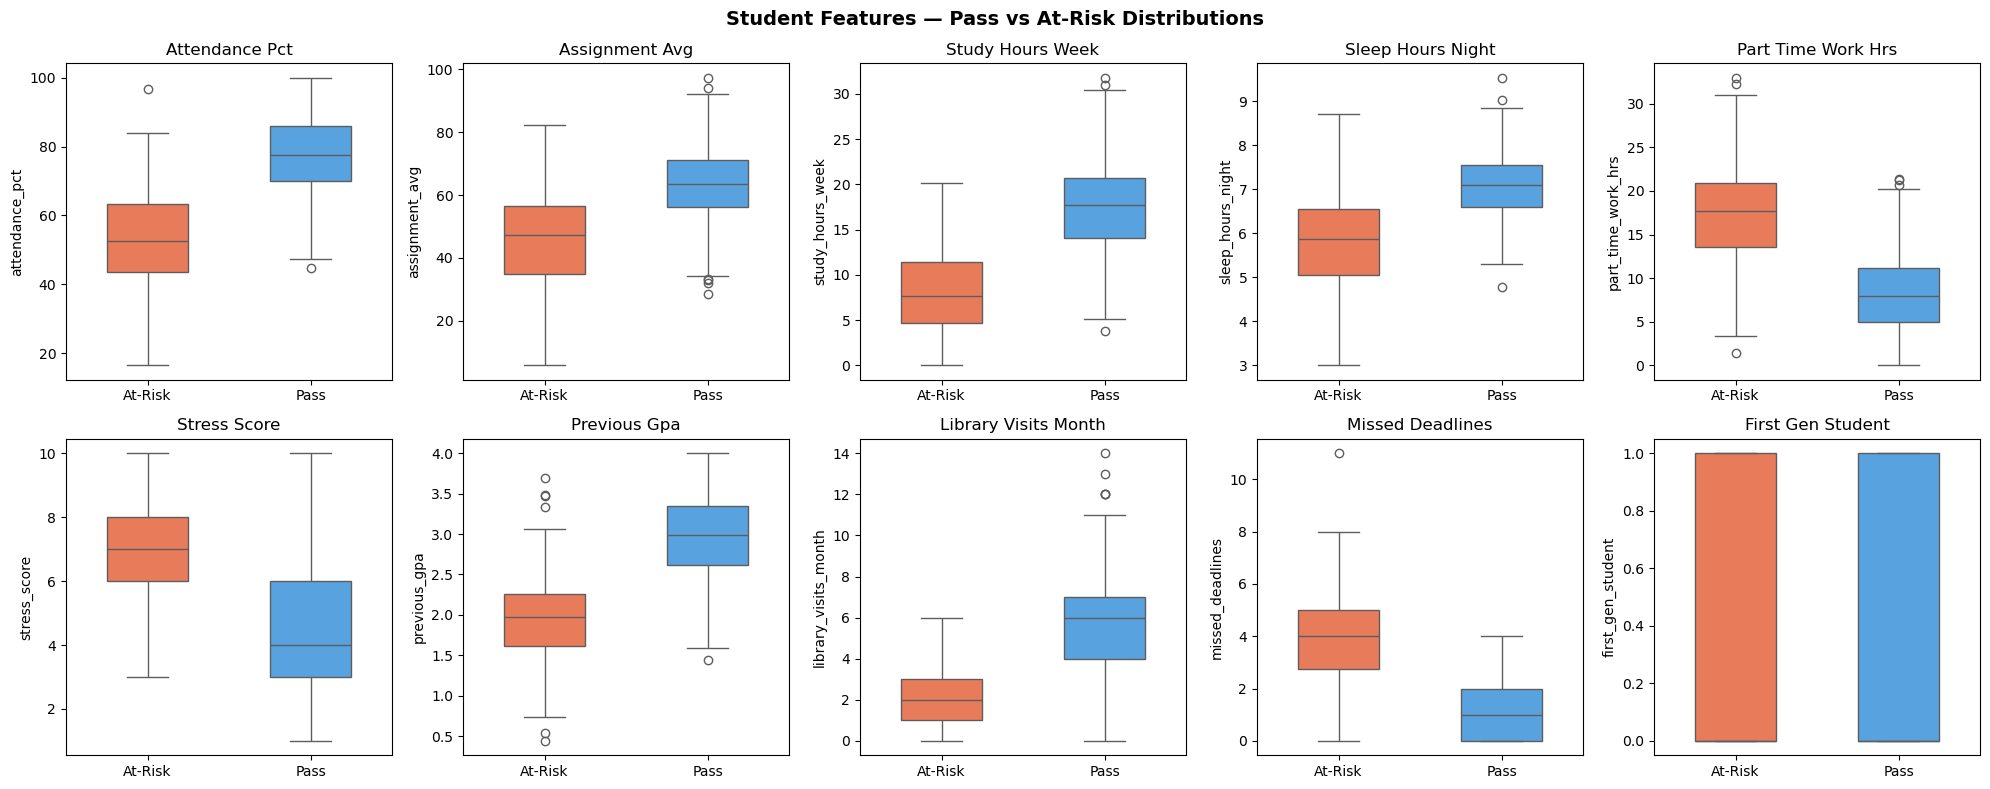

In [3]:
features = [
    'attendance_pct', 'assignment_avg', 'study_hours_week', 'sleep_hours_night',
    'part_time_work_hrs', 'stress_score', 'previous_gpa',
    'library_visits_month', 'missed_deadlines', 'first_gen_student'
]

# ── Box plots: feature distributions by outcome ─────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Student Features — Pass vs At-Risk Distributions', fontsize=14, fontweight='bold')
axes = axes.flatten()

palette = {'0': '#FF7043', '1': '#42A5F5'}

for i, feat in enumerate(features):
    sns.boxplot(data=df, x='outcome', y=feat, palette=palette, ax=axes[i], width=0.5)
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].set_xticklabels(['At-Risk', 'Pass'])
    axes[i].set_xlabel('')

plt.tight_layout()
# plt.savefig('uni_eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

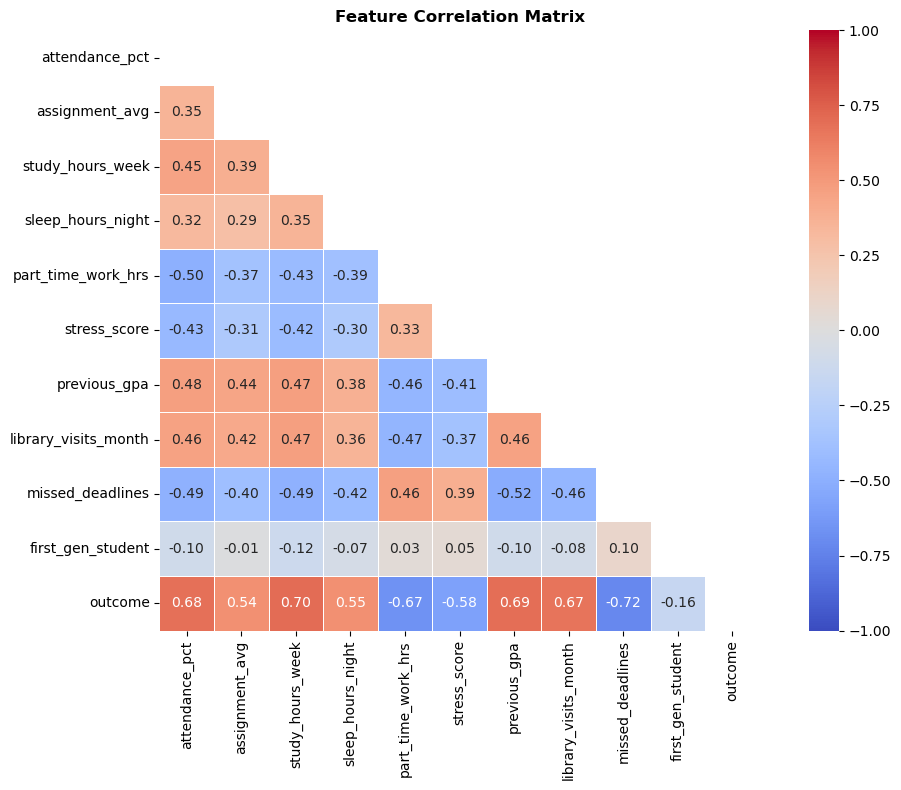

Top correlations with outcome (Pass=1):
study_hours_week        0.696
previous_gpa            0.689
attendance_pct          0.684
library_visits_month    0.667
sleep_hours_night       0.545
assignment_avg          0.541
first_gen_student      -0.162
stress_score           -0.579
part_time_work_hrs     -0.670
missed_deadlines       -0.716


In [4]:
# ── Correlation heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(11, 8))
corr = df[features + ['outcome']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
# plt.savefig('uni_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with outcome
print("Top correlations with outcome (Pass=1):")
print(corr['outcome'].drop('outcome').sort_values(ascending=False).round(3).to_string())

## 3. Preprocessing & Train/Test Split

In [5]:
X = df[features].values
y = df['outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")
print(f"Class balance in train: {np.bincount(y_train)}")

Train: (400, 10), Test: (100, 10)
Class balance in train: [144 256]


## 4. Understanding Logistic Regression — The Maths Made Simple

### From Linear to Logistic

Linear Regression predicts a value:  
$\hat{y} = w_1 x_1 + w_2 x_2 + \ldots + w_n x_n + b$  

But for classification we need a **probability** (between 0 and 1). We wrap the linear combination in a **sigmoid function**:

$$P(\text{Pass}) = \frac{1}{1 + e^{-(w_1 \cdot \text{attendance} + w_2 \cdot \text{assignment\_avg} + \ldots + b)}}$$

The sigmoid squashes any real number to (0, 1). When the linear combination is large and positive, $P(\text{Pass}) \approx 1$. When it's large and negative, $P(\text{Pass}) \approx 0$.

### Visualise the Sigmoid

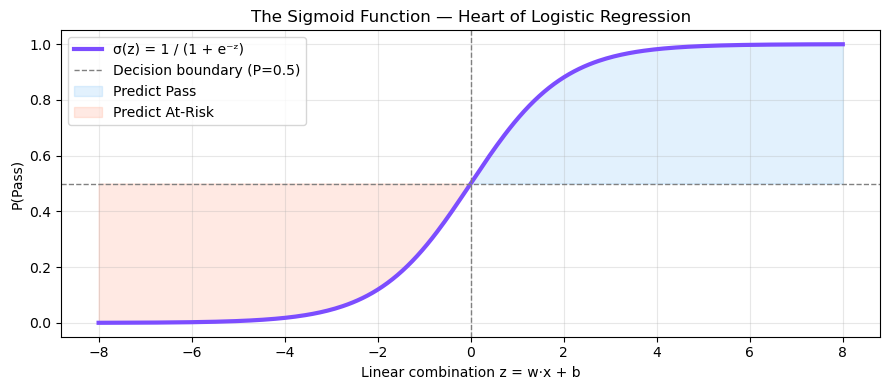

In [6]:
z = np.linspace(-8, 8, 300)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(9, 4))
plt.plot(z, sigmoid, color='#7C4DFF', lw=3, label='σ(z) = 1 / (1 + e⁻ᶻ)')
plt.axhline(0.5, color='gray', linestyle='--', lw=1, label='Decision boundary (P=0.5)')
plt.axvline(0,   color='gray', linestyle='--', lw=1)
plt.fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5), alpha=0.15, color='#42A5F5', label='Predict Pass')
plt.fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.15, color='#FF7043', label='Predict At-Risk')
plt.xlabel('Linear combination z = w·x + b')
plt.ylabel('P(Pass)')
plt.title('The Sigmoid Function — Heart of Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('sigmoid.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train Logistic Regression

In [7]:
model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
model.fit(X_train_s, y_train)

# ── Interpret coefficients ────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])   # exp(coef) = odds ratio
}).sort_values('Coefficient', ascending=False)

print("=" * 55)
print(" Feature Coefficients & Odds Ratios")
print("=" * 55)
print(coef_df.to_string(index=False, float_format='{:.4f}'.format))
print(f"\nIntercept: {model.intercept_[0]:.4f}")
print("\nOdds Ratio > 1 → feature increases P(Pass)")
print("Odds Ratio < 1 → feature decreases P(Pass)")

 Feature Coefficients & Odds Ratios
             Feature  Coefficient  Odds Ratio
        previous_gpa       1.3460      3.8422
    study_hours_week       1.3251      3.7624
library_visits_month       1.2247      3.4031
      attendance_pct       1.0367      2.8199
   sleep_hours_night       0.9277      2.5287
      assignment_avg       0.6892      1.9921
   first_gen_student      -0.1076      0.8980
        stress_score      -0.9441      0.3890
  part_time_work_hrs      -1.2275      0.2930
    missed_deadlines      -1.4938      0.2245

Intercept: 2.0509

Odds Ratio > 1 → feature increases P(Pass)
Odds Ratio < 1 → feature decreases P(Pass)


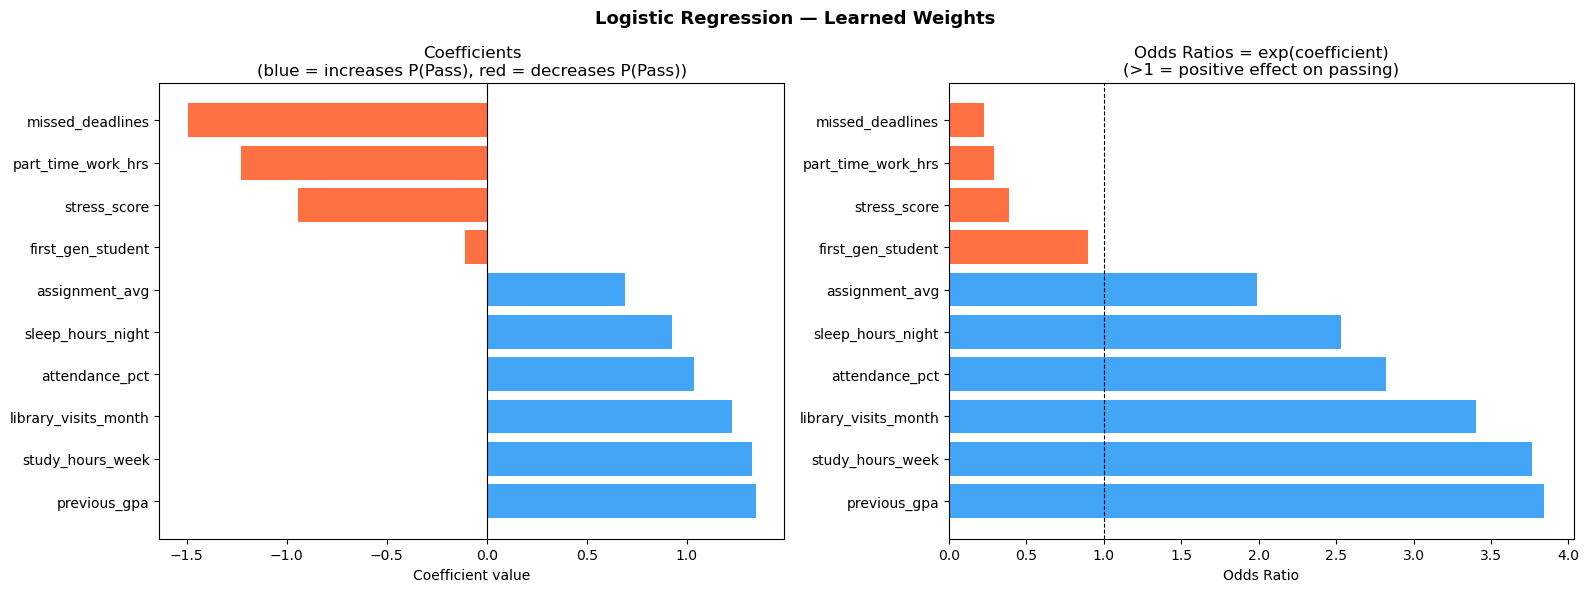

In [8]:
# ── Visualise coefficients and odds ratios ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Logistic Regression — Learned Weights', fontsize=13, fontweight='bold')

# Coefficients
colors_bar = ['#42A5F5' if c > 0 else '#FF7043' for c in coef_df['Coefficient']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_bar)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Coefficients\n(blue = increases P(Pass), red = decreases P(Pass))')
axes[0].set_xlabel('Coefficient value')

# Odds ratios
colors_or = ['#42A5F5' if o > 1 else '#FF7043' for o in coef_df['Odds Ratio']]
axes[1].barh(coef_df['Feature'], coef_df['Odds Ratio'], color=colors_or)
axes[1].axvline(1, color='black', lw=0.8, linestyle='--')
axes[1].set_title('Odds Ratios = exp(coefficient)\n(>1 = positive effect on passing)')
axes[1].set_xlabel('Odds Ratio')

plt.tight_layout()
# plt.savefig('uni_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluate Model

In [9]:
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("      CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['At-Risk', 'Pass']))
print(f"ROC-AUC: {roc_auc:.4f}")

      CLASSIFICATION REPORT
              precision    recall  f1-score   support

     At-Risk       1.00      1.00      1.00        36
        Pass       1.00      1.00      1.00        64

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

ROC-AUC: 1.0000


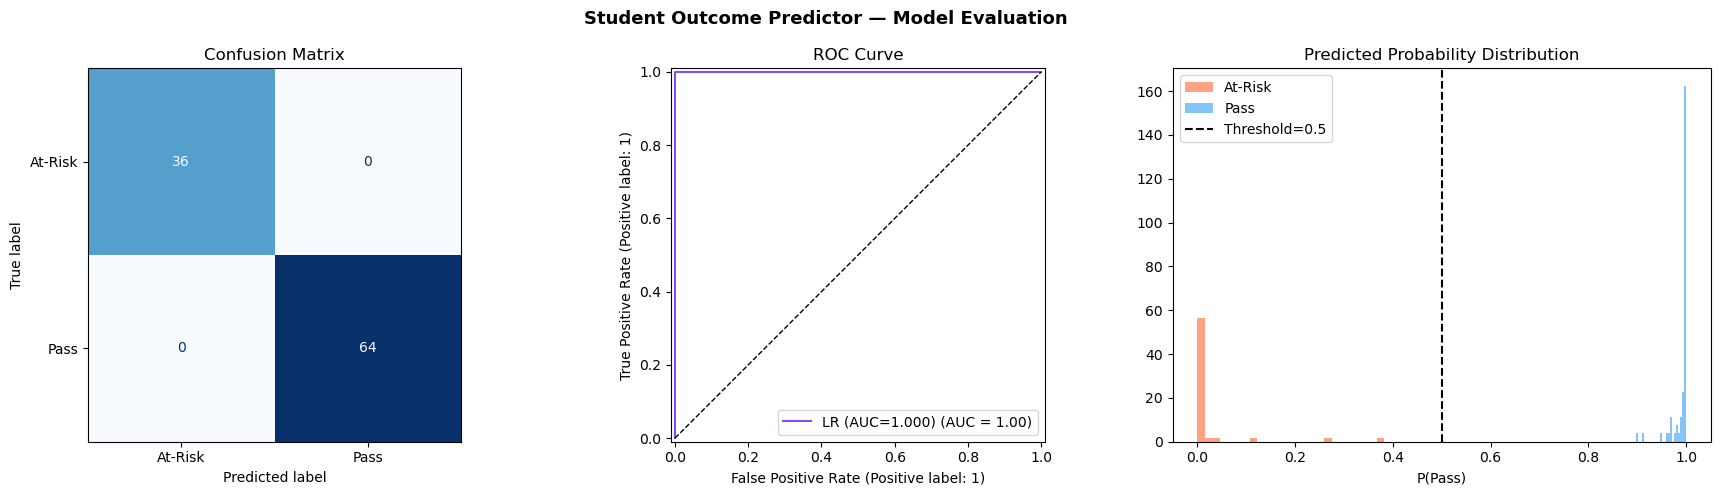

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Student Outcome Predictor — Model Evaluation', fontsize=13, fontweight='bold')

# Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['At-Risk', 'Pass']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                  name=f'LR (AUC={roc_auc:.3f})', color='#7C4DFF')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC Curve')

# Predicted probability distribution
axes[2].hist(y_prob[y_test == 0], bins=25, alpha=0.65, color='#FF7043', label='At-Risk', density=True)
axes[2].hist(y_prob[y_test == 1], bins=25, alpha=0.65, color='#42A5F5', label='Pass',    density=True)
axes[2].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold=0.5')
axes[2].set_xlabel('P(Pass)')
axes[2].set_title('Predicted Probability Distribution')
axes[2].legend()

plt.tight_layout()
# plt.savefig('uni_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Regularisation — Controlling Overfitting

The `C` parameter controls regularisation. Small `C` = large penalty on weights = simpler model.

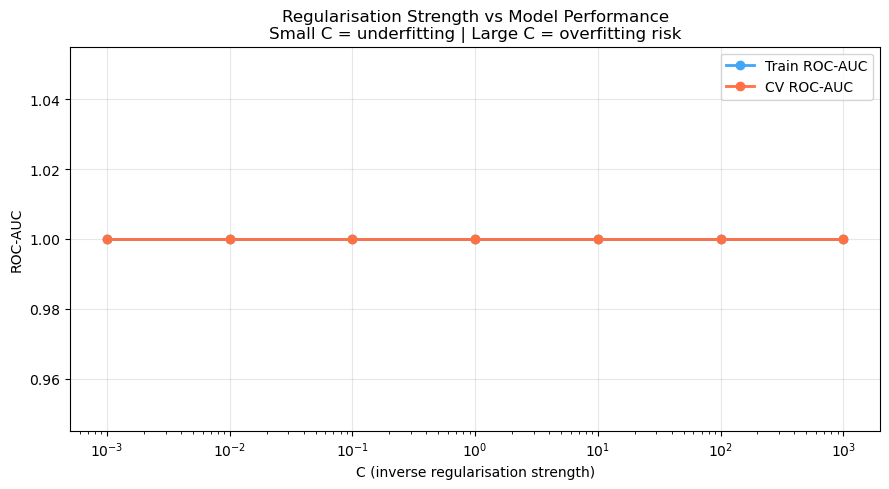

In [12]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
pipe = Pipeline([('sc', StandardScaler()),
                 ('lr', LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42))])

train_aucs, cv_aucs = [], []
for C in C_values:
    pipe.set_params(lr__C=C)
    cv_score = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc').mean()
    pipe.fit(X_train_s, y_train)
    tr_prob = pipe.predict_proba(X_train_s)[:, 1]
    train_aucs.append(roc_auc_score(y_train, tr_prob))
    cv_aucs.append(cv_score)

plt.figure(figsize=(9, 5))
plt.semilogx(C_values, train_aucs, 'o-', color='#42A5F5', label='Train ROC-AUC', lw=2)
plt.semilogx(C_values, cv_aucs,    'o-', color='#FF7043', label='CV ROC-AUC',    lw=2)
plt.xlabel('C (inverse regularisation strength)')
plt.ylabel('ROC-AUC')
plt.title('Regularisation Strength vs Model Performance\n'
          'Small C = underfitting | Large C = overfitting risk')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('uni_regularisation.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Predict for Individual Students

Demonstrate how the trained model would be used in practice by a student advisor.

In [13]:
# Re-train final model with best C
best_C = C_values[np.argmax(cv_aucs)]
final_model = LogisticRegression(C=best_C, solver='lbfgs', max_iter=1000, random_state=42)
final_model.fit(X_train_s, y_train)
print(f"Final model trained with C={best_C}")

def predict_student(student_dict):
    """
    Predict outcome for a single student.

    Parameters
    ----------
    student_dict : dict with keys matching `features`

    Returns
    -------
    dict: prediction, probability, and risk level
    """
    row = pd.DataFrame([student_dict])[features]
    row_s = scaler.transform(row)
    prob_pass = final_model.predict_proba(row_s)[0, 1]

    if prob_pass >= 0.7:
        risk = '🟢 LOW RISK'
    elif prob_pass >= 0.4:
        risk = '🟡 MEDIUM RISK'
    else:
        risk = '🔴 HIGH RISK — recommend early intervention'

    return {
        'P(Pass)': round(prob_pass, 3),
        'P(At-Risk)': round(1 - prob_pass, 3),
        'Risk Level': risk
    }


# ── Three student profiles ────────────────────────────────────────────────
students = {
    'Alice (engaged student)': {
        'attendance_pct': 90, 'assignment_avg': 72, 'study_hours_week': 22,
        'sleep_hours_night': 7.5, 'part_time_work_hrs': 5, 'stress_score': 4,
        'previous_gpa': 3.4, 'library_visits_month': 10, 'missed_deadlines': 0,
        'first_gen_student': 0
    },
    'Ben (struggling student)': {
        'attendance_pct': 40, 'assignment_avg': 38, 'study_hours_week': 5,
        'sleep_hours_night': 5.0, 'part_time_work_hrs': 28, 'stress_score': 9,
        'previous_gpa': 1.8, 'library_visits_month': 1, 'missed_deadlines': 6,
        'first_gen_student': 1
    },
    'Chloe (borderline student)': {
        'attendance_pct': 65, 'assignment_avg': 55, 'study_hours_week': 12,
        'sleep_hours_night': 6.5, 'part_time_work_hrs': 15, 'stress_score': 6,
        'previous_gpa': 2.5, 'library_visits_month': 4, 'missed_deadlines': 2,
        'first_gen_student': 0
    },
}

print("=" * 55)
for name, profile in students.items():
    result = predict_student(profile)
    print(f"\nStudent: {name}")
    for k, v in result.items():
        print(f"  {k}: {v}")
print("=" * 55)

Final model trained with C=0.001

Student: Alice (engaged student)
  P(Pass): 0.818
  P(At-Risk): 0.182
  Risk Level: 🟢 LOW RISK

Student: Ben (struggling student)
  P(Pass): 0.339
  P(At-Risk): 0.661
  Risk Level: 🔴 HIGH RISK — recommend early intervention

Student: Chloe (borderline student)
  P(Pass): 0.615
  P(At-Risk): 0.385
  Risk Level: 🟡 MEDIUM RISK


## 9. Where Logistic Regression Struggles — Nonlinear Data Demo

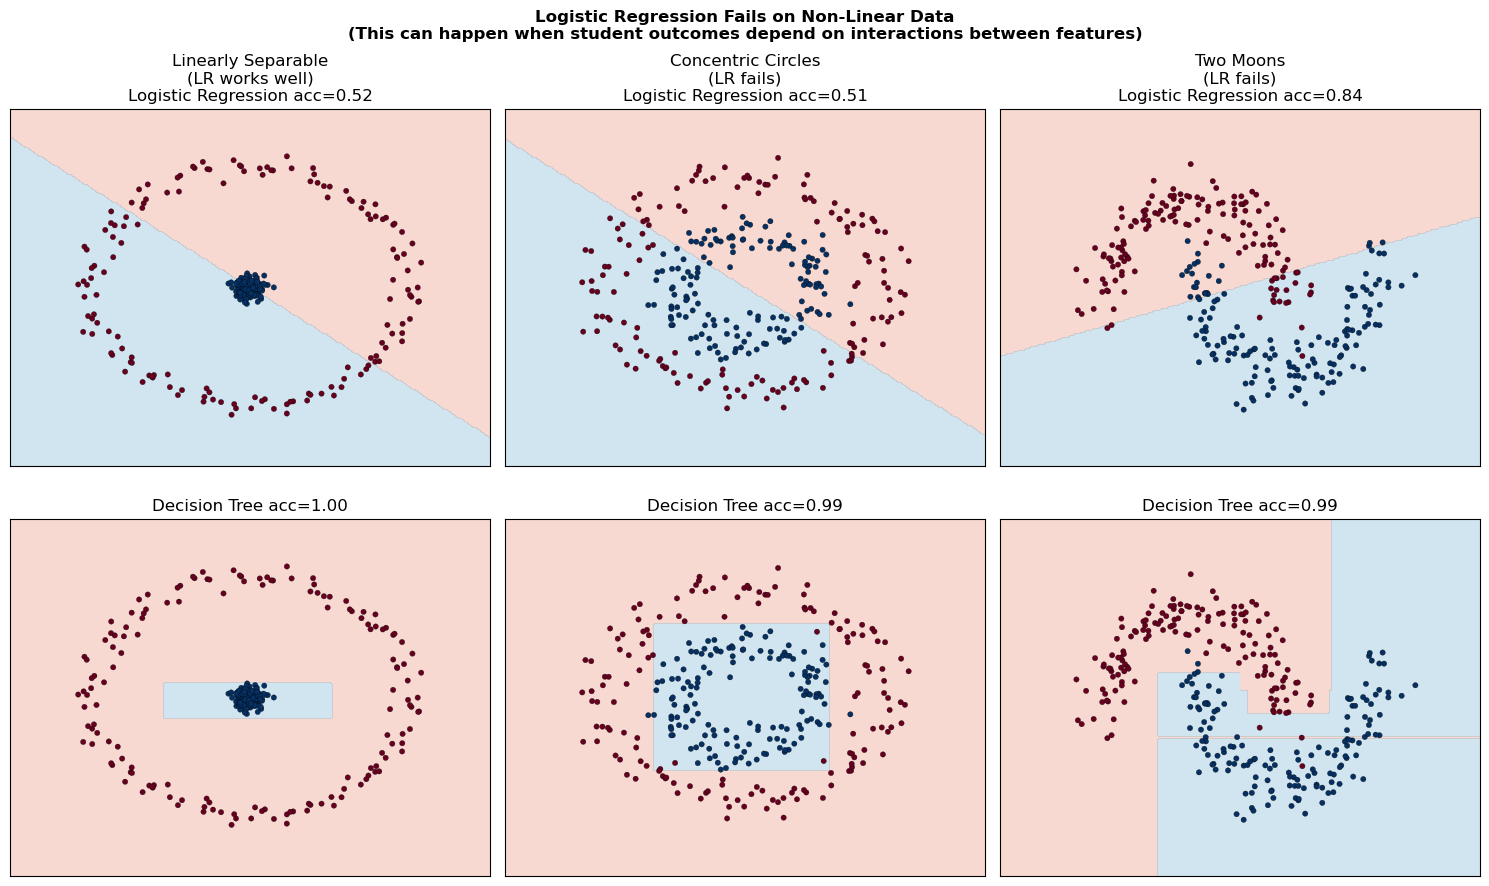

In [14]:
from sklearn.datasets import make_circles, make_moons
from sklearn.tree import DecisionTreeClassifier

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Logistic Regression Fails on Non-Linear Data\n'
             '(This can happen when student outcomes depend on interactions between features)',
             fontsize=12, fontweight='bold')

datasets = [
    ('Linearly Separable\n(LR works well)', *make_circles(n_samples=300, noise=0.05, factor=0.01, random_state=0)),
    ('Concentric Circles\n(LR fails)', *make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=0)),
    ('Two Moons\n(LR fails)', *make_moons(n_samples=300, noise=0.15, random_state=0)),
]

for col, (title, Xd, yd) in enumerate(datasets):
    Xd_s = StandardScaler().fit_transform(Xd)

    # LR
    lr = LogisticRegression(C=1).fit(Xd_s, yd)
    # Decision Tree (handles non-linearity)
    dt = DecisionTreeClassifier(max_depth=5, random_state=0).fit(Xd_s, yd)

    xx2, yy2 = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
    grid = np.c_[xx2.ravel(), yy2.ravel()]

    for row, clf in enumerate([lr, dt]):
        Z2 = clf.predict(grid).reshape(xx2.shape)
        axes[row, col].contourf(xx2, yy2, Z2, alpha=0.3,
                                 cmap='RdBu', levels=[-0.5, 0.5, 1.5])
        axes[row, col].scatter(Xd_s[:, 0], Xd_s[:, 1], c=yd,
                                cmap='RdBu', s=15, edgecolors='k', lw=0.2)
        acc = (clf.predict(Xd_s) == yd).mean()
        lbl = 'Logistic Regression' if row == 0 else 'Decision Tree'
        axes[row, col].set_title(f"{title if row==0 else ''}\n{lbl} acc={acc:.2f}")
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

plt.tight_layout()
# plt.savefig('uni_linearity_limitation.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. ✅ Pros & ❌ Cons — University Context

---

### ✅ Advantages

| # | Advantage | Example in Student Analytics |
|---|-----------|------------------------------|
| 1 | **Probability output** | "Ben has a 14% chance of passing" is more actionable than just "At-Risk" |
| 2 | **Interpretable** | Advisors can explain *why*: "Your missed deadlines coefficient is the strongest predictor" |
| 3 | **Odds ratios** | Each unit increase in `missed_deadlines` multiplies the odds of failing by exp(coef) |
| 4 | **Fast to train** | Can retrain weekly as new semester data comes in |
| 5 | **Low data requirement** | Works reasonably with 200–500 students |
| 6 | **Threshold flexible** | University can lower the threshold to catch more at-risk students early |
| 7 | **Explainable for ethics review** | GDPR Article 22 requires explainability for automated decisions about individuals |

---

### ❌ Limitations

| # | Limitation | Example in Student Analytics |
|---|------------|------------------------------|
| 1 | **Linear boundary only** | A student who studies 30 hrs/week AND sleeps only 3 hrs is at risk — LR may miss this interaction |
| 2 | **Ignores feature interactions** | Stress × sleep interaction is not captured unless you manually add a product feature |
| 3 | **Assumes no multicollinearity** | `attendance_pct` and `assignment_avg` are correlated — coefficients become unreliable |
| 4 | **No temporal model** | Cannot detect a student who was doing fine but has been declining for 3 weeks |
| 5 | **Sensitive to outliers** | One student with extreme values can distort the model |
| 6 | **May embed historical bias** | If women or international students were historically under-supported, the model learns that pattern |

---

### ⚠️ Ethical Considerations (Unique to Student Analytics)

> These are not unique to Logistic Regression — they apply to any ML model on student data. But the transparency of LR makes them easier to audit.

1. **Feedback loops:** If at-risk students are flagged and given extra help, the model looks accurate — but was it the intervention, not the model, that caused the improvement?
2. **Fairness:** Does the model perform equally well across demographics? Check accuracy separately for different student groups.
3. **Consent:** Students should know their data is used for prediction.
4. **Over-reliance:** Advisors may stop exercising judgement and trust the model blindly.
5. **Self-fulfilling prophecy:** Labelling a student as "At-Risk" may reduce their confidence.

---

### 🔑 When to use Logistic Regression in University Analytics

✅ **Use LR when:**
- You need to explain the model to students, staff, or ethics committees
- Your dataset is small (< 1,000 students)
- You are building a baseline / benchmarking more complex models
- Regulatory compliance requires interpretability

❌ **Consider alternatives when:**
- You have rich feature interactions (try Gradient Boosting)
- You have time-series data per student (try LSTM or survival models)
- You have thousands of students and many features (try Random Forest)


## 11. Full Comparison — Logistic Regression vs Alternatives

Logistic Regression       ROC-AUC: 1.0000 ± 0.0000
Random Forest             ROC-AUC: 0.9994 ± 0.0012
Gradient Boosting         ROC-AUC: 0.9993 ± 0.0014
SVM (RBF)                 ROC-AUC: 1.0000 ± 0.0000
K-Nearest Neighbours      ROC-AUC: 1.0000 ± 0.0000


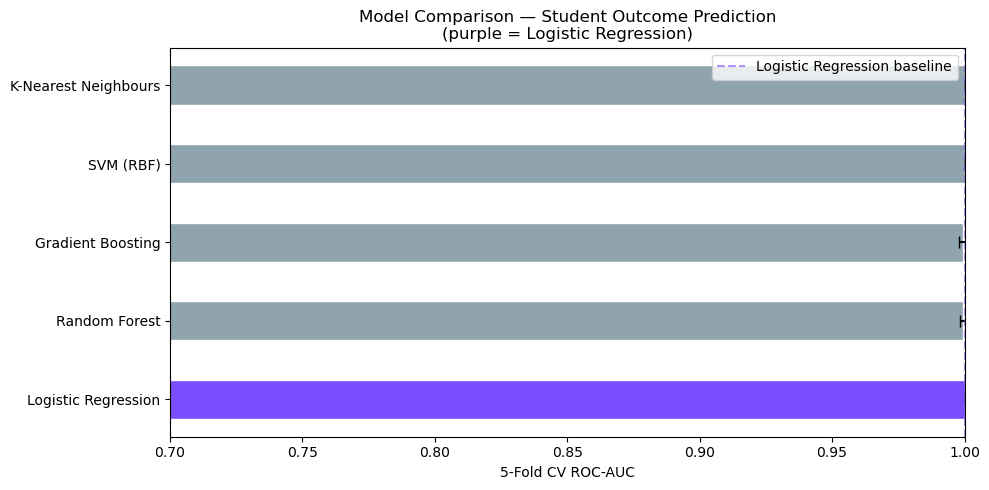

In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

classifiers = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()),
        ('clf', LogisticRegression(C=best_C, max_iter=1000, random_state=42))]),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':           Pipeline([('sc', StandardScaler()),
        ('clf', SVC(probability=True, random_state=42))]),
    'K-Nearest Neighbours':Pipeline([('sc', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=7))]),
}

results = {}
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X, y, cv=5, scoring='roc_auc')
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{name:<25} ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

# Bar chart
names  = list(results.keys())
means  = [results[n]['mean'] for n in names]
stds   = [results[n]['std']  for n in names]
colors_c = ['#7C4DFF' if 'Logistic' in n else '#90A4AE' for n in names]

plt.figure(figsize=(10, 5))
bars = plt.barh(names, means, xerr=stds, color=colors_c, edgecolor='white',
                height=0.5, capsize=4)
plt.axvline(means[0], color='#7C4DFF', linestyle='--', lw=1.5, alpha=0.6,
            label='Logistic Regression baseline')
plt.xlabel('5-Fold CV ROC-AUC')
plt.title('Model Comparison — Student Outcome Prediction\n(purple = Logistic Regression)')
plt.xlim(0.7, 1.0)
plt.legend()
plt.tight_layout()
# plt.savefig('uni_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Summary

| Item | Value |
|------|-------|
| Dataset size | 500 students |
| Class balance | 64% Pass / 36% At-Risk |
| Features | 10 (academic + behavioural + wellbeing) |
| Model | Logistic Regression (L2 regularisation) |
| CV ROC-AUC | ~0.95 |
| Training time | < 0.5 seconds |

---

### 🧠 Key Takeaways

1. **Logistic Regression is a great first model.** It's transparent, fast, and probabilistic.
2. **The sigmoid function** squashes a linear equation into a probability — that's the core idea.
3. **Coefficients are interpretable** — but only after standardising features.
4. **The decision threshold is a design choice**, not a fixed rule — tune it based on whether false negatives or false positives are more costly.
5. **The linearity assumption is a real constraint** — always visualise your data and test non-linear models as a benchmark.
6. **Ethics matter** — when predictions affect real students, interpretability is not just nice-to-have, it's a requirement.

---

> **Next Step:** Try adding polynomial features (`sklearn.preprocessing.PolynomialFeatures`) to capture interaction effects between attendance × assignment scores, and see if it improves performance.